# Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Load Data

In [2]:
df = pd.read_csv(r"..\data\Imalanced_product_reviews.csv", encoding='latin-1')

print("Imbalanced_product_reviews dataset shape:", df.shape)


Imbalanced_product_reviews dataset shape: (6332, 3)


# View Data

In [3]:

print("\nImbalanced_product_reviews dataset:")
df.head()
df.tail()
df.sample(5)
df.info()
df.describe()




Imbalanced_product_reviews dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6332 entries, 0 to 6331
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rating        6332 non-null   int64 
 1   Review        6332 non-null   object
 2   ReviewLength  6332 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 148.5+ KB


,Rating,ReviewLength
count,6332.000000,6332.000000
mean,3.349968,665.431775
std,1.235912,602.425489
min,1.000000,6.000000
25%,2.750000,257.000000
50%,3.500000,474.500000
75%,4.000000,879.000000
max,5.000000,4882.000000


#  Selecting Columns

In [4]:
df = df[['Rating','Review']]

print("Imbalanced_product_reviews dataset columns:", df.columns)

print("Imbalanced_product_reviews dataset shape:", df.shape)


Imbalanced_product_reviews dataset columns: Index(['Rating', 'Review'], dtype='object')
Imbalanced_product_reviews dataset shape: (6332, 2)


# Data Visualization of Imbalanced Data

# Rating Distribution (Bar Chart)

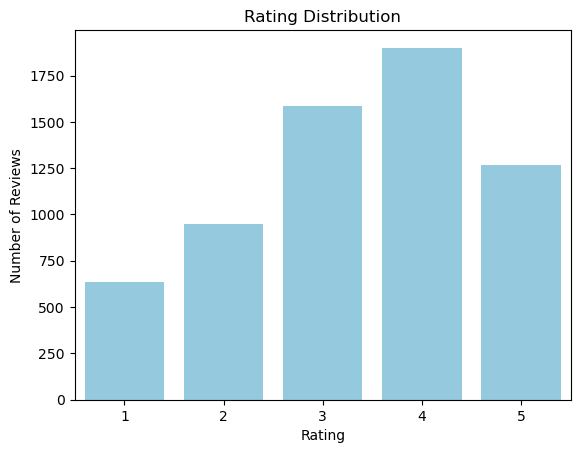

In [5]:
sns.countplot(x='Rating', data=df, color='skyblue')  
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

# Rating Distribution (Pie Chart)

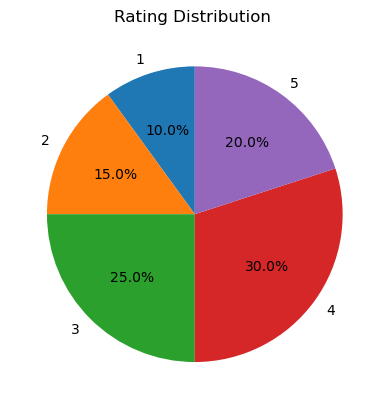

In [6]:

rating_counts = df['Rating'].value_counts().sort_index()

# Labels and values
categories = rating_counts.index
values = rating_counts.values

# Plot pie chart
plt.pie(values, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title("Rating Distribution ")
plt.show()


# Natural Language Processing (NLP)

# Lowercase All Text

In [7]:
df = df[['Rating', 'Review']]
# Convert Review text to lowercase
df['Review'] = df['Review'].str.lower()
# Reset index
df.reset_index(drop=True, inplace=True)

print(df.head())
print("Dataset shape:", df.shape)


   Rating                                             Review
0       1  needs a new name now the pischkes of old had s...
1       1  their alcohol slushies are undrinkable and are...
2       1  oh boy i usually love mucho gusto but no me gu...
3       1  this is one of the franchise store of ritz cam...
4       1  if we were able to give 0 stars i would ask to...
Dataset shape: (6332, 2)


# Remove URL

In [8]:
def remove_url(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub('', text)  # Replace URLs with empty string

df['Review'] = df['Review'].apply(remove_url)

df['Review'].head()


0    needs a new name now the pischkes of old had s...
1    their alcohol slushies are undrinkable and are...
2    oh boy i usually love mucho gusto but no me gu...
3    this is one of the franchise store of ritz cam...
4    if we were able to give 0 stars i would ask to...
Name: Review, dtype: object

# Remove HTML tags

In [9]:
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'',text)
df['Review'] =df['Review'].apply(remove_html_tags)

df['Review'].head()

0    needs a new name now the pischkes of old had s...
1    their alcohol slushies are undrinkable and are...
2    oh boy i usually love mucho gusto but no me gu...
3    this is one of the franchise store of ritz cam...
4    if we were able to give 0 stars i would ask to...
Name: Review, dtype: object

# Remove emojis, punctuation and special characters

In [10]:
import string

punctuation_list = string.punctuation
print(f'The punctuations are {punctuation_list}')



The punctuations are !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [11]:
def clean_text_punct(text):
    # Remove punctuation
    for char in punctuation_list:
        text = text.replace(char, '')
    # Remove extra spaces
    text = ' '.join(text.split())
    return text

df['Review'] = df['Review'].apply(clean_text_punct)
df['Review'].head()

0    needs a new name now the pischkes of old had s...
1    their alcohol slushies are undrinkable and are...
2    oh boy i usually love mucho gusto but no me gu...
3    this is one of the franchise store of ritz cam...
4    if we were able to give 0 stars i would ask to...
Name: Review, dtype: object

# Showing stopwords 

In [12]:
import spacy
nlp = spacy.load("en_core_web_sm")

def show_stopwords_in_text(text):
    doc = nlp(text)
    present_stopwords = [token.text for token in doc if token.is_stop]
    return present_stopwords

df['Stopwords_in_Review'] = df['Review'].apply(show_stopwords_in_text)
df[['Review', 'Stopwords_in_Review']].head()

,Review,Stopwords_in_Review
0,needs a new name now the pischkes of old had s...,"[a, name, now, the, of, had, such, a, i, to, k..."
1,their alcohol slushies are undrinkable and are...,"[their, are, and, are, of, as, as, the, its, y..."
2,oh boy i usually love mucho gusto but no me gu...,"[i, but, no, me, we, a, to, go, perhaps, that,..."
3,this is one of the franchise store of ritz cam...,"[this, is, one, of, the, of, in, the, are, how..."
4,if we were able to give 0 stars i would ask to...,"[if, we, were, to, give, i, would, to, give, i..."


# Remove stopwords

In [13]:
def remove_stopwords(text):
    doc = nlp(text)
    filtered_text = " ".join([token.text for token in doc if not token.is_stop])
    return filtered_text

df['Review'] = df['Review'].apply(remove_stopwords)
df['Review'].head()


0    needs new pischkes old sad ending appreciated ...
1    alcohol slushies undrinkable sure case gut rot...
2    oh boy usually love mucho gusto gusta today go...
3    franchise store ritz camera chandler stores st...
4    able 0 stars ask 1 live nearby sad coffeeshop ...
Name: Review, dtype: object

# Apply Lemmatization

In [14]:
def lemmatize_text(text):
    doc = nlp(text)
    lemma_list = [token.lemma_ for token in doc]   # list format
    lemma_joined = " ".join(lemma_list)            # joined format
    return lemma_list, lemma_joined

# Apply and expand into two columns
df[['Review_List', 'REVIEW']] = df['Review'].apply(lambda x: pd.Series(lemmatize_text(x)))

print("List format:\n", df['Review_List'].head())
print("\nJoined format:\n", df['REVIEW'].head())



List format:
 0    [need, new, pischke, old, sad, end, appreciate...
1    [alcohol, slushie, undrinkable, sure, case, gu...
2    [oh, boy, usually, love, mucho, gusto, gusta, ...
3    [franchise, store, ritz, camera, chandler, sto...
4    [able, 0, star, ask, 1, live, nearby, sad, cof...
Name: Review_List, dtype: object

Joined format:
 0    need new pischke old sad end appreciated mcgra...
1    alcohol slushie undrinkable sure case gut rot ...
2    oh boy usually love mucho gusto gusta today ge...
3    franchise store ritz camera chandler store sta...
4    able 0 star ask 1 live nearby sad coffeeshop s...
Name: REVIEW, dtype: object


# Filter out reviews with: Fewer than minimum words and Excessively long text

In [15]:
# Calculate word count for each review
df['Word_Count'] = df['REVIEW'].apply(lambda x: len(x.split()))

df = df[(df['Word_Count'] >= 3) & (df['Word_Count'] <= 250)]

# Check the filtered dataset
print("Original dataset shape:", df.shape)
print("Filtered dataset shape:", df.shape)
df[['REVIEW', 'Word_Count']].head()


Original dataset shape: (6272, 6)
Filtered dataset shape: (6272, 6)


,REVIEW,Word_Count
0,need new pischke old sad end appreciated mcgra...,52
1,alcohol slushie undrinkable sure case gut rot ...,17
2,oh boy usually love mucho gusto gusta today ge...,90
3,franchise store ritz camera chandler store sta...,58
4,able 0 star ask 1 live nearby sad coffeeshop s...,165


# Data Visualization

# Bar plot: Review count per rating

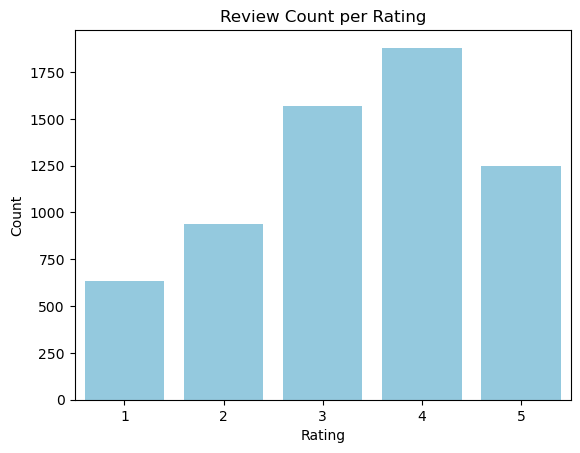

In [16]:
sns.countplot(x='Rating', data=df, color='skyblue')
plt.title('Review Count per Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Word count 

In [17]:
df.loc[:, 'Word_Count'] = df['REVIEW'].str.split().str.len()

df[['REVIEW', 'Word_Count']].head()



,REVIEW,Word_Count
0,need new pischke old sad end appreciated mcgra...,52
1,alcohol slushie undrinkable sure case gut rot ...,17
2,oh boy usually love mucho gusto gusta today ge...,90
3,franchise store ritz camera chandler store sta...,58
4,able 0 star ask 1 live nearby sad coffeeshop s...,165


# Histogram for Word Count

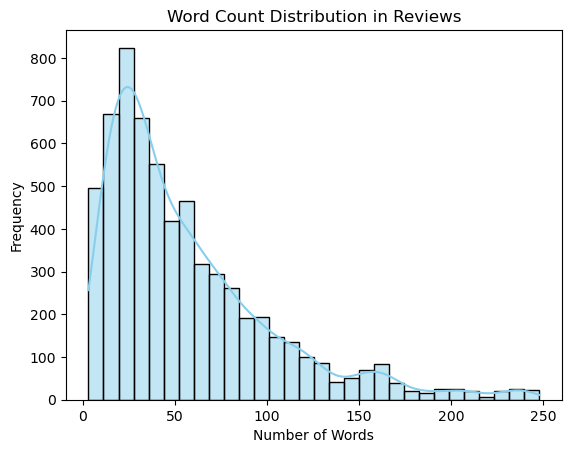

In [18]:

sns.histplot(df['Word_Count'], bins=30, kde=True, color='skyblue')
plt.title('Word Count Distribution in Reviews')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Box Plot: Word count by Rating

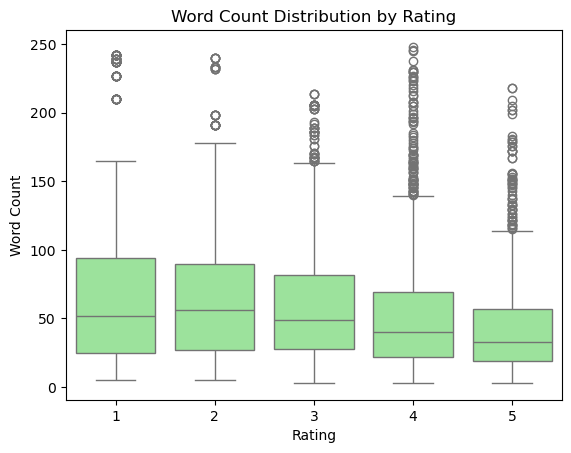

In [19]:


sns.boxplot(x='Rating', y='Word_Count', data=df, color='lightgreen')
plt.title('Word Count Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.show()

# full sample reviews per rating

In [20]:
for rating, group in df.groupby('Rating'):
    print(f"\n--- Rating: {rating} ---\n")
    sample_reviews = df[df['Rating'] == rating]['REVIEW'].sample(
        n=min(5, len(df[df['Rating'] == rating])),
        random_state=42)
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review}\n")



--- Rating: 1 ---

1. owner change hand place not want date paper quality productgo scrap happy crop girl

2. lazy q closed 2010 new owner clean place call jester billiard ton beer ac smoking patio pool table redo table get new cue rockin

3. clean bad gel manicure ruin nailsjimmy finished wife start nail sand thin talk people look away theye file sand cut cut times thumb nail cause catch tear day soon 10 12yr old daughter bring color pick precocous customer focusedshe narcisstic want adult wait open bottle look gel colorno sample gel dry machine sit priority mail box chair customer wait area pedicure okay will not come place like vietnamese want money not understand service cleanliness come place try nickle dime price instance deal gel previous manicure get new gel manicure want use dremel sand nail quick healthy nail return visit place m surprised stay business sadly category clean jimmy stay away nail customer quiet girl cute customer come 12year old wait thank

4. alcohol slushie 

# Shuffle the dataset

In [21]:
# Shuffle the balanced dataset
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_shuffled[['REVIEW', 'Rating']].head()


,REVIEW,Rating
0,take student lead historical tour disappoint t...,4
1,come sister cher like place m food prepare coo...,3
2,visit daniel bergerjone local history guide gu...,4
3,place get effort think fall slightly short nea...,3
4,love sprinkle cupcake manage location 3 cal li...,5


# Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X = df['REVIEW']   # Text data
y = df['Rating']          # Target labels

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))


Training set size: 5017
Test set size: 1255


# Preprocessing

In [23]:

nlp = spacy.load('en_core_web_sm')

def spacy_preprocess(text):
    doc = nlp(text.lower())  # Lowercase and tokenize
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return ' '.join(tokens)


In [24]:
# Preprocess training set
X_train_processed = X_train.apply(spacy_preprocess)

# Preprocess test set
X_test_processed = X_test.apply(spacy_preprocess)

print("X_train_preprocessed:")
print(X_train_processed.head())
print("X_test_preprocessed:")
print(X_test_processed.head())



X_train_preprocessed:
5067    gspot addict limit week hubby date night weeke...
658     dinner people monday night server people servi...
6124    yes pricey membership yes membership pricey fr...
5680    concerns heirloom food fantastic star fantasti...
3029    decent potsticker kind good know expect meet e...
Name: REVIEW, dtype: object
X_test_preprocessed:
3827    recommendation brotheri owe beer great food bb...
498     clean bad gel manicure ruin nailsjimmy finishe...
2701    interesting way spend hour lot display dusty i...
1897    craving night figure wanted happen stumble pla...
2032    sure place atmosphere good drink menu prioriti...
Name: REVIEW, dtype: object


# Vectorize text using:TF-IDF

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2), stop_words='english')

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
print("TF-IDF training set shape:", X_train_tfidf.shape)

X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)
print("TF-IDF test set shape:", X_test_tfidf.shape)



TF-IDF training set shape: (5017, 5000)
TF-IDF test set shape: (1255, 5000)


In [26]:
print("Number of features in TF-IDF:", len(tfidf_vectorizer.get_feature_names_out()))
print("Sample features:", tfidf_vectorizer.get_feature_names_out()[:30])


Number of features in TF-IDF: 5000
Sample features: ['able' 'able star' 'absolute' 'absolutely' 'absolutely love' 'ac'
 'academic' 'accept' 'acceptable' 'access' 'accessible' 'accident'
 'accommodate' 'accomodate' 'accompany' 'accomplish' 'accomplish steam'
 'accumulate' 'accumulate burn' 'acknowledge' 'acquire' 'act' 'act like'
 'action' 'action order' 'actual' 'actual storefront' 'actually'
 'actually comingsomeday' 'actually pretty']


# Original Reviews and Ratings for Training and Test Sets

In [27]:
# Training set
print("REVIEW and Rating from training set:")
train_df_sample = pd.DataFrame({'REVIEW': X_train, 'Rating': y_train}).reset_index(drop=True)
print(train_df_sample.head(), "\n")  # Added \n for separation

# Test set
print("REVIEW and Rating from test set:")
test_df_sample = pd.DataFrame({'REVIEW': X_test, 'Rating': y_test}).reset_index(drop=True)
print(test_df_sample.head())


REVIEW and Rating from training set:
                                              REVIEW  Rating
0  gspot addict limit go week take hubby date nig...       5
1  go dinner 6 people monday night 2 server 6 peo...       2
2  yes pricey get membership yes membership price...       5
3  concerns heirloom food fantastic 5 star fantas...       5
4  decent potsticker kind good not know expect me...       3 

REVIEW and Rating from test set:
                                              REVIEW  Rating
0  go recommendation brotheri owe beer great food...       4
1  clean bad gel manicure ruin nailsjimmy finishe...       1
2  interesting way spend hour lot display dusty i...       3
3  craving night not figure wanted happen stumble...       3
4  sure place atmosphere good drink menu prioriti...       3


# Top TF-IDF Features per Review with Corresponding Ratings

In [30]:

def top_tfidf_features_per_review(tfidf_matrix, feature_names, ratings, top_n=5):
  
    # Ensure dense format
    if not isinstance(tfidf_matrix, np.ndarray):
        tfidf_dense = tfidf_matrix.toarray()
    else:
        tfidf_dense = tfidf_matrix

    top_features_list = []

    for i in range(tfidf_dense.shape[0]):
        row = tfidf_dense[i]
        top_indices = row.argsort()[-top_n:][::-1]  # Indices of top N features
        top_features = [feature_names[idx] for idx in top_indices]
        top_scores = [row[idx] for idx in top_indices]
        
        top_features_list.append({
            'Rating': ratings.iloc[i] if hasattr(ratings, 'iloc') else ratings[i],
            'Top_Features': top_features,
            'TF-IDF_Scores': top_scores
        })

    return pd.DataFrame(top_features_list)

feature_names = tfidf_vectorizer.get_feature_names_out()
top_features_df = top_tfidf_features_per_review(X_train_tfidf, feature_names, y_train, top_n=5)

top_features_df.head()


,Rating,Top_Features,TF-IDF_Scores
0,5,"[gelato, mint, flatbread, awesome, photo]","[0.5919406463734193, 0.29355685539805454, 0.28..."
1,2,"[dinner, blue cheese, come dry, stay open, ent...","[0.2019661932534202, 0.19843095769482902, 0.19..."
2,5,"[membership, pricey, ll, yes, exhibit]","[0.49283176566587655, 0.3693003139777653, 0.30..."
3,5,"[fantastic, concern, place, budget, visit place]","[0.2964771547527294, 0.2489364828799885, 0.159..."
4,3,"[stuff, know expect, delightful, impressive, d...","[0.349340483142634, 0.280793726410251, 0.25604..."


In [32]:
top_features_df.tail()

,Rating,Top_Features,TF-IDF_Scores
5012,5,"[di, mi, del, la, ad]","[0.6980421654420247, 0.31820023653563756, 0.28..."
5013,5,"[fry chicken, lunch dinner, reasonable price, ...","[0.2952159174940334, 0.26746232122731345, 0.26..."
5014,1,"[enemy, send, bad, place, zichini]","[0.7256678264990264, 0.5589711948677747, 0.345..."
5015,5,"[harvard, tour harvard, great experience, weat...","[0.3398843217762929, 0.3178325103158891, 0.312..."
5016,4,"[watch, ear, target, plug, place watch]","[0.23249265142356482, 0.2023837254647344, 0.19..."


# Convert TF-IDF Matrices to DataFrames

In [33]:

feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert TF-IDF matrix to DataFrame
tfidf_df_train = pd.DataFrame(X_train_tfidf.toarray(), columns=feature_names)

# Add Rating column
tfidf_df_train['Rating'] = y_train.reset_index(drop=True)


tfidf_df_train.head()

,able,able star,absolute,absolutely,absolutely love,ac,academic,accept,acceptable,access,...,zero,zero star,zichini,zichini bell,zinc,zona,zu,zuccini,zuccini warn,Rating
0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.13038,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
3,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
4,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [34]:
tfidf_df_train.tail()

,able,able star,absolute,absolutely,absolutely love,ac,academic,accept,acceptable,access,...,zero,zero star,zichini,zichini bell,zinc,zona,zu,zuccini,zuccini warn,Rating
5012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
5013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
5014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
5015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
5016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.192915,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
